# Trimming Pipeline

In [12]:
import librosa
import soundfile as sf
import IPython.display as ipd

In [24]:
# Función para reproducir audios
def play_audio(audio_path):
    return ipd.Audio(audio_path)

In [43]:
input_path = "/home/pepelacasa/MM-PR-01568-audio_replay_attacks/audios/D_1000001_telephone_alaw_ffmpeg.wav"
output_path = "/home/pepelacasa/MM-PR-01568-audio_replay_attacks/audios/D_1000001_telephone_alaw_ffmpeg_trimming.wav"
top_db = 30

In [44]:
play_audio(input_path)

In [45]:
y, sr = librosa.load(input_path, sr=8000)
y_trimmed = librosa.effects.trim(y, top_db=top_db)[0]

In [46]:
sf.write(output_path, y_trimmed, sr)

In [47]:
play_audio(output_path)

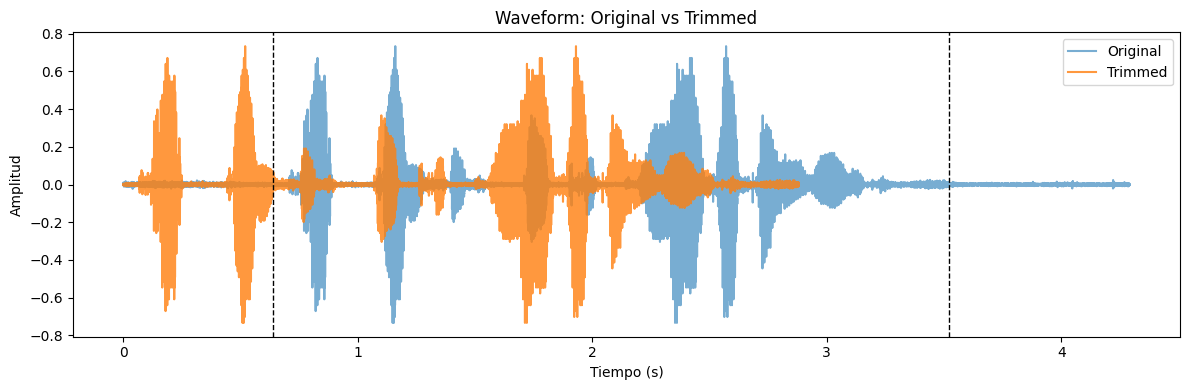

In [42]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

# Carga y trimming
y, sr = librosa.load('/home/pepelacasa/MM-PR-01568-audio_replay_attacks/audios/D_1000001_telephone_alaw_ffmpeg.wav', sr=8000)
y_trimmed, (start, end) = librosa.effects.trim(y, top_db=30)

# Crear eje de tiempos
t_orig    = np.arange(len(y)) / sr
t_trimmed = np.arange(len(y_trimmed)) / sr

# Plot
plt.figure(figsize=(12,4))
plt.plot(t_orig,    y,         label='Original', alpha=0.6)
plt.plot(t_trimmed, y_trimmed, label='Trimmed',  alpha=0.8)
plt.axvline(start/sr, color='k', ls='--', lw=1)
plt.axvline(end/sr,   color='k', ls='--', lw=1)
plt.title('Waveform: Original vs Trimmed')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.tight_layout()
plt.show()
